# Guide RNA assignment

This notebook very closely follows the "Guide RNA assignment" tutorial on pertpy's website (https://pertpy.readthedocs.io/en/latest/tutorials/notebooks/guide_rna_assignment.html), just to familiarize myself with syntax and perturb-seq workflow.

Here, let's demonstrate how to visualize guide RNAs per cell.

## Setup

In [1]:
import jax.numpy as jnp
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc
import scipy
import seaborn as sns
from matplotlib import pyplot as plt
from jax import random

C:\Users\CT\Documents\post_phd_training\omics_sandbox_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulate data
This function generates a toy dataset with simulated CRISPR guide assignments. There are `n_guides` guides in total.
There are positive and negative cell populations, sampled from a Gaussian and Poisson distribution, respectively.

In [2]:
def generate_toy_data(n_guides: int = 2, n_cells_per_group: int = 50):
    dats = []
    for i in range(n_guides):
        key = random.PRNGKey(i)
        key1, key2, key3 = random.split(key, num=3)

        # Negative first
        poisson_data = random.poisson(key1, lam=0.1, shape=(n_cells_per_group * i,)).astype(jnp.float32)
        if i == 1:  # Add a double positive population for the second guide
            poisson_data = random.normal(key3, shape=(n_cells_per_group,)) * 1.0 + 3
            poisson_data = poisson_data.clip(0.0, None)

        # Positive
        gaussian_data = random.normal(key2, shape=(n_cells_per_group,)) * 1.0 + 3
        gaussian_data = gaussian_data.clip(0.0, None)

        # Negative second
        poisson_data_ = random.poisson(key1, lam=0.1, shape=(n_cells_per_group * (n_guides - i - 1),)).astype(
            jnp.float32
        )

        # The count vector for one guide is the concatenation of the negative and positive populations
        guide_data = jnp.hstack([poisson_data, gaussian_data, poisson_data_])
        dats.append(guide_data)
    guide_counts = np.array(jnp.vstack(dats)).T

    # Combine Poisson and Gaussian data into one dataset
    adata = sc.AnnData(
        guide_counts,
        obs=pd.DataFrame(index=[f"cell{i + 1}" for i in range(guide_counts.shape[0])]),
        var=pd.DataFrame(index=[f"guide{i + 1}" for i in range(guide_counts.shape[1])]),
    )
    adata.obs["ground_truth"] = ["guide" + str(i + 1) for i in range(n_guides) for _ in range(n_cells_per_group)]
    col = adata.obs["ground_truth"].copy()
    col.iloc[:n_cells_per_group] = "guide1+guide2"
    adata.obs["ground_truth"] = col
    return adata

Let's use this function to generate a small simulated dataset of 3 guides, 50 cells per guide. The first cell population is positive for guide 1 and 2 simultaneously.

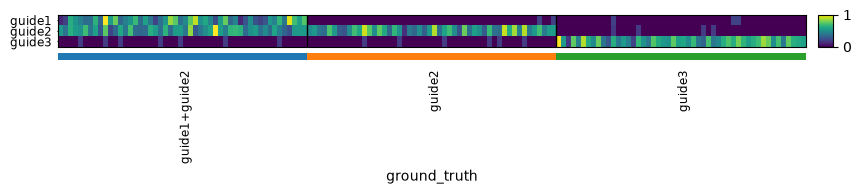

In [3]:
adata = generate_toy_data(n_guides=3, n_cells_per_group=50)
sc.pl.heatmap(
    adata, groupby="ground_truth", cmap="viridis", standard_scale="var", var_names=adata.var_names, swap_axes=True
)

Let's convert the data to a dataframe and visualize it more directly

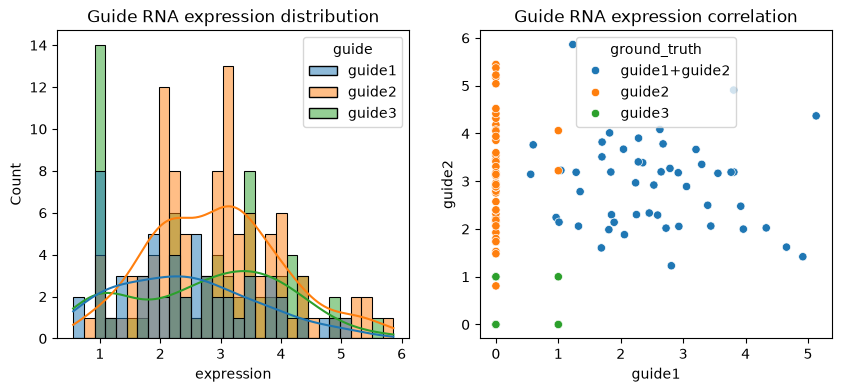

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

df = adata.to_df().stack().reset_index().rename(columns={"level_0": "cell", "level_1": "guide", 0: "expression"})
df = df[df.expression > 0]
sns.histplot(df, x="expression", hue="guide", bins=30, kde=True, ax=axs[0])
axs[0].set_title("Guide RNA expression distribution")

df = adata.to_df()
sns.scatterplot(data=df, x="guide1", y="guide2", hue=adata.obs["ground_truth"], ax=axs[1])
axs[1].set_title("Guide RNA expression correlation")

plt.show()

## Mixture model for guide assignment
First, let's try to fit a Poisson-Gaussian mixture model to the data in order to assign each cell to the guide with highest probability. The mixture model assumes up-front that negative populations are Poisson-distributed, while positive populations are Gaussian-distributed.

This is notably how this toy dataset was constructed in the first place.

In [5]:
guide_assign = pt.pp.GuideAssignment()
guide_assign.assign_mixture_model(adata, assigned_guides_key="assigned_guide_mixture_model")

In [6]:
adata.obs

,ground_truth,assigned_guide_mixture_model
cell1,guide1+guide2,negative
cell2,guide1+guide2,negative
cell3,guide1+guide2,negative
cell4,guide1+guide2,negative
cell5,guide1+guide2,negative
...,...,...
cell146,guide3,negative
cell147,guide3,negative
cell148,guide3,negative
cell149,guide3,negative


Now we can compare the ACTUAL v/s the INFERRED guide expression for each cell

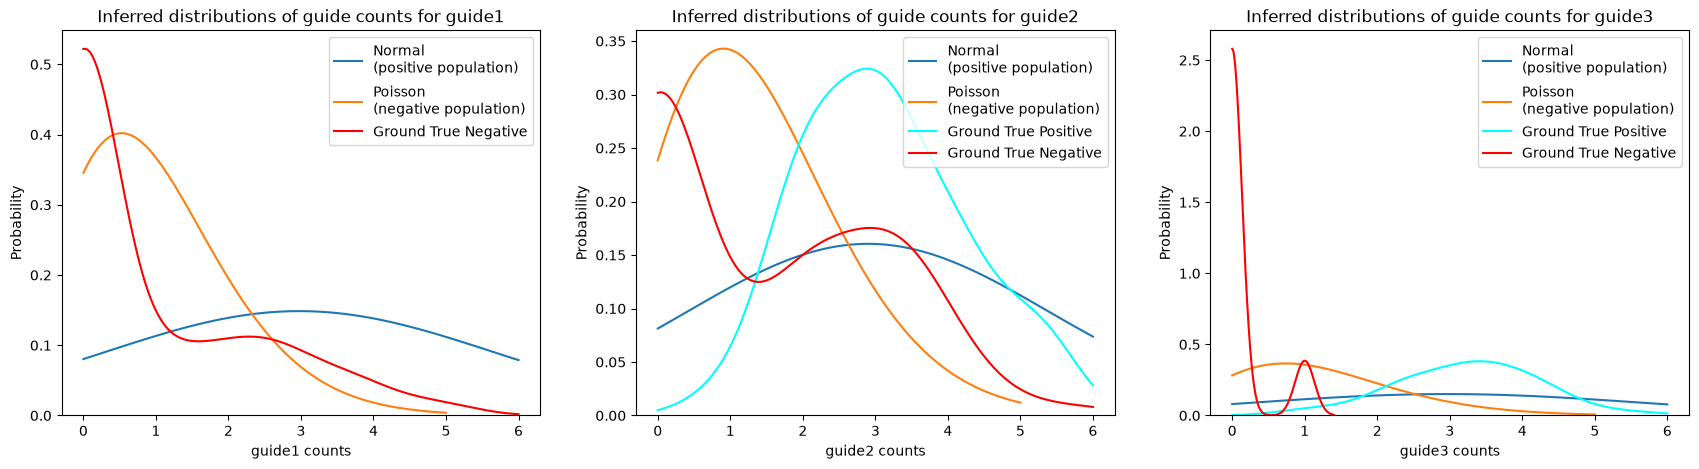

In [7]:
import numpyro.distributions as dist

# plot probability distributions of model
n_guides = len(adata.var_names)
guides = adata.var_names
fig, axs = plt.subplots(1, n_guides, figsize=(7 * n_guides, 5))
for ax, guide in zip(axs, guides):
    # plot gaussian distribution
    x = np.linspace(0, 6, 100)
    y = dist.Normal(
        adata.var.loc[guide, "gaussian_mean"],
        adata.var.loc[guide, "gaussian_std"],
    ).log_prob(x)
    ax.plot(x, np.exp(y), label="Normal\n(positive population)")
    # plot poisson distribution
    x = np.linspace(0, 5, 100)
    y = dist.Poisson(adata.var.loc[guide, "poisson_rate"]).log_prob(x)
    ax.plot(x, np.exp(y), label="Poisson\n(negative population)")

    # Plot ground truth empirical distribution
    sns.kdeplot(
        np.ravel(adata[adata.obs.ground_truth == guide, guide].X),
        color="cyan",
        label="Ground True Positive",
        ax=ax,
        clip=(0, 6),
    )
    sns.kdeplot(
        np.ravel(adata[adata.obs.ground_truth != guide, guide].X),
        color="red",
        label="Ground True Negative",
        ax=ax,
        clip=(0, 6),
    )

    ax.set_xlabel(f"{guide} counts")
    ax.set_ylabel("Probability")
    ax.legend()
    ax.set_title(f"Inferred distributions of guide counts for {guide}")

plt.show()

We had already **assigned** which cell should be positive/negative for each guide, so we can evaluate the performance of this guide assignment.

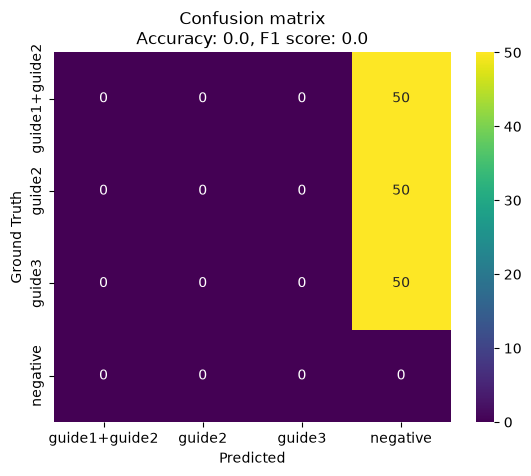

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

accuracy = accuracy_score(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"])
f1 = f1_score(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"], average="weighted")

all_labels = np.union1d(adata.obs["ground_truth"].unique(), np.unique(adata.obs["assigned_guide_mixture_model"]))

cm = confusion_matrix(adata.obs["ground_truth"], adata.obs["assigned_guide_mixture_model"], labels=all_labels)
cm_df = pd.DataFrame(cm, index=all_labels, columns=all_labels)

ax = sns.heatmap(cm_df, annot=True, fmt="d", cmap="viridis")
ax.set_ylabel("Ground Truth")
ax.set_xlabel("Predicted")
plt.title(f"Confusion matrix\nAccuracy: {np.round(accuracy, 2)}, F1 score: {np.round(f1, 2)}")
plt.show()

NOTE: for some reason, the guide distributions I am getting do NOT match those in the tutorial. I do not know whether this is a library version issue, but using the exact same code gives me nothing but negative labels using the mixture model. I guess it would've been nice if random seeds were consistent between the published tutorial and the code generated here, and I'm unsure where exactly I would look.

At least I'm getting an idea of how this would be done.

## Threshold model for guide assignment
This time, let's use a threshold or a maximum guide count to assign guides.

In [9]:
guide_assign.assign_by_threshold(adata, assignment_threshold=1, output_layer="assigned_guide_threshold")
guide_assign.assign_to_max_guide(adata, assignment_threshold=1, obs_key="assigned_guide_max")

# Convert the threshold assignment to a string
matrix = adata.layers["assigned_guide_threshold"]
result = []
for row in np.asarray(matrix):  # Convert to a standard 2D array
    indices = [f"guide{i + 1}" for i, val in enumerate(row) if val == 1]
    result.append("+".join(indices) if indices else None)
adata.obs["assigned_guide_threshold"] = result
adata.obs.loc[adata.obs["assigned_guide_threshold"].isna(), "assigned_guide_threshold"] = "Negative"

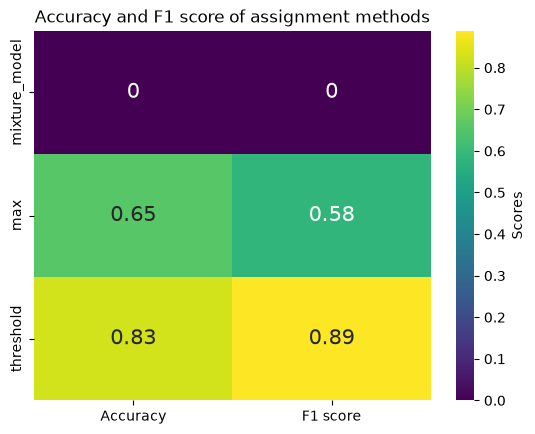

In [10]:
evaluation = {}
for key in ["assigned_guide_mixture_model", "assigned_guide_max", "assigned_guide_threshold"]:
    evaluation[key] = (
        accuracy_score(adata.obs["ground_truth"], adata.obs[key]),
        f1_score(adata.obs["ground_truth"], adata.obs[key], average="weighted"),
    )
df = pd.DataFrame(evaluation, index=["Accuracy", "F1 score"]).T
df.index = df.index.str.replace("assigned_guide_", "")
sns.heatmap(df, annot=True, cmap="viridis", annot_kws={"size": 15}, cbar_kws={"label": "Scores"})
plt.title("Accuracy and F1 score of assignment methods")
plt.show()

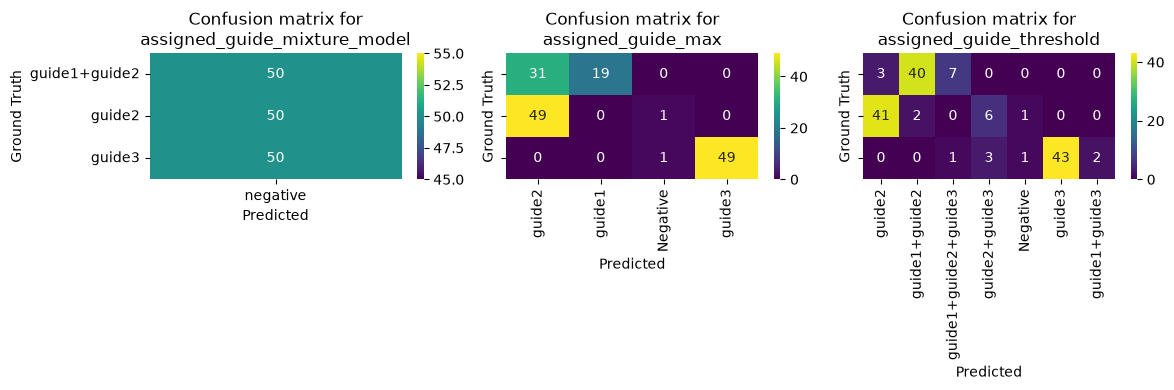

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(4 * 3, 4), sharey=True)
for ax, key in zip(axs, ["assigned_guide_mixture_model", "assigned_guide_max", "assigned_guide_threshold"]):
    gt_labels = adata.obs["ground_truth"].unique()
    pred_labels = adata.obs[key].unique()
    all_labels = np.union1d(gt_labels, pred_labels)

    cm = confusion_matrix(adata.obs["ground_truth"], adata.obs[key], labels=all_labels)
    cm = pd.DataFrame(cm, index=all_labels, columns=all_labels)
    cm = cm.loc[gt_labels, pred_labels]

    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", ax=ax)
    ax.set_ylabel("Ground Truth")
    ax.set_xlabel("Predicted")
    ax.set_title(f"Confusion matrix for\n{key}")
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

While I don't know exactly why the simulations cause the mixture modeling to break, but we can see that using the max approach is not very optimal.

## Real data

This data is the Papalexi (2021) dataset.

In [12]:
mdata = pt.dt.papalexi_2021()
# seems like an error in the original data
mdata.mod["gdo"].X = scipy.sparse.csr_matrix(mdata.mod["gdo"].X.toarray() - 1)
mdata.push_obs(columns=["gdo:guide_ID"], mods="gdo")
gdo = mdata.mod["gdo"]
gdo

C:\Users\CT\Documents\post_phd_training\omics_sandbox_venv\Lib\site-packages\mudata\_core\mudata.py:1416: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=0, join_common=join_common)


AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'nCount_GDO', 'guide_ID'
    var: 'name'
    layers: None (.X)

`gdo` will contain the guide RNA expression values per cell. First, let's transform the counts with the usual log transformation

In [13]:
gdo.layers["counts"] = gdo.X.copy()
sc.pp.log1p(gdo)
gdo

AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'nCount_GDO', 'guide_ID'
    var: 'name'
    uns: 'log1p'
    layers: None (.X), 'counts'

Next, let's visualize the expression of guides per cell

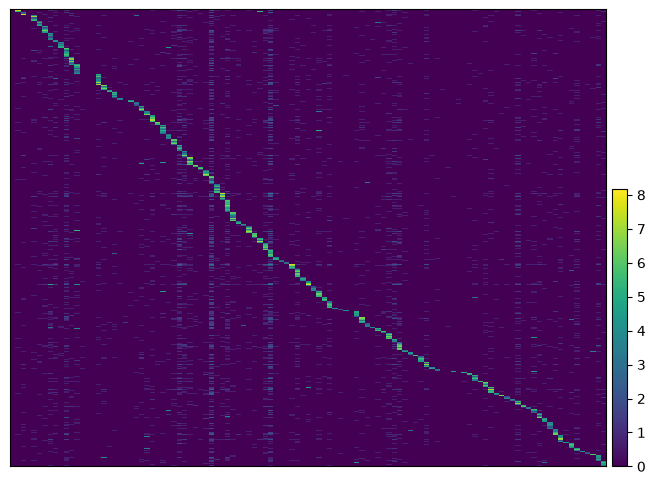

In [14]:
ga = pt.pp.GuideAssignment()
ga.plot_heatmap(gdo, key_to_save_order="plot_order")

Using a max approach to assign guide RNAs actually does a great job in matching the actual guide assignment

In [15]:
ga.assign_to_max_guide(gdo, assignment_threshold=5, layer='counts', obs_key='assigned_guide_max')

sum(gdo.obs['assigned_guide_max'] != gdo.obs['guide_ID'])

0

Why not try a mixture model with this data? Let's subset so we don't spend as long on the computation.

In [28]:
gdo_smol = gdo[:5000, :10].copy()
gdo_smol.X = gdo_smol.layers['counts'].copy()

In [29]:
ga = pt.pp.GuideAssignment()
ga.assign_mixture_model(gdo_smol, assigned_guides_key="assigned_guide_mix_model", show_progress=True)

C:\Users\CT\AppData\Local\Python\pythoncore-3.14-64\Lib\functools.py:1069: UserWarning: Skipping eGFPg1 as there are less than 2 cells expressing the guide at all.
  return self._dispatch(args[0].__class__).__get__(self._obj, self._cls)(*args, **kwargs)


Fitting Poisson-Gaussian mixture for 9 guides in parallel.


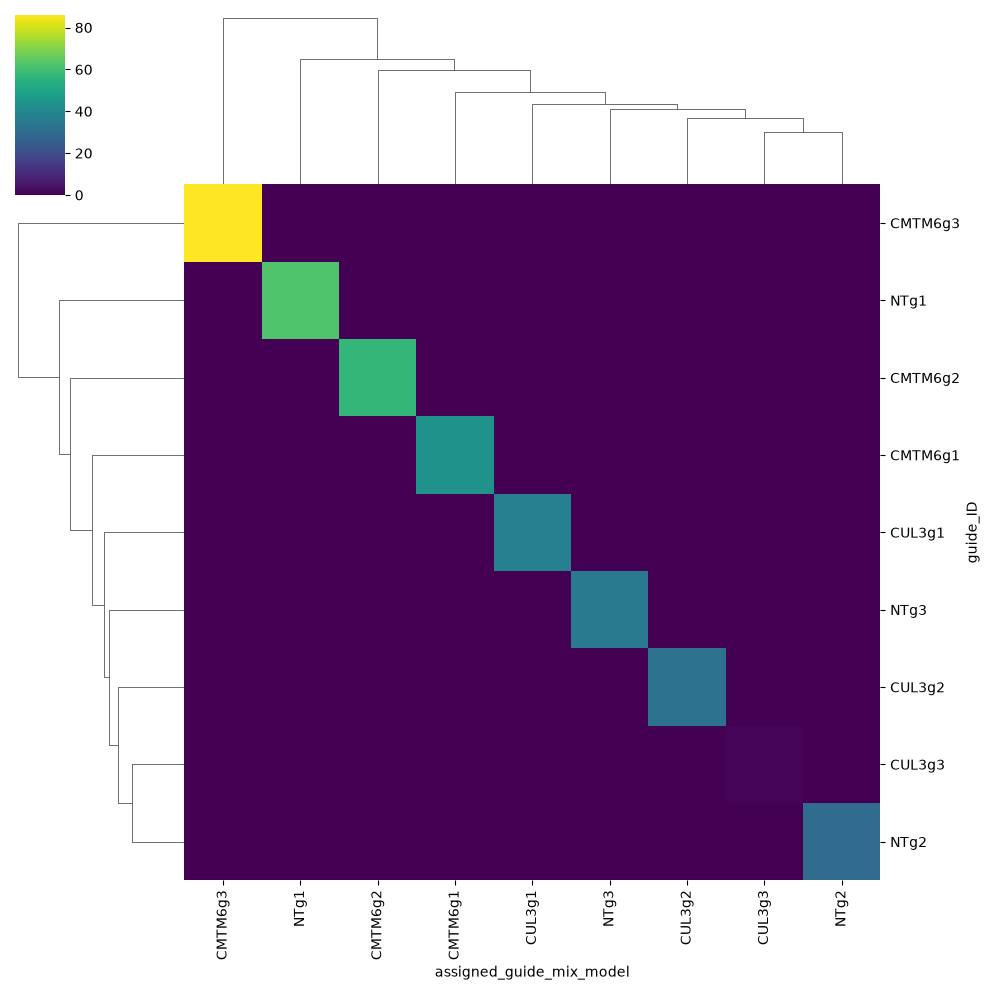

In [34]:
pdf = (
    gdo_smol.obs[["guide_ID", "assigned_guide_mix_model"]]
    .value_counts()
    .reset_index()
    .rename(columns={0: "count"})
    .pivot(index="guide_ID", columns="assigned_guide_mix_model", values="count")
    .fillna(0)
)
fitted_guides = np.intersect1d(gdo_smol.var_names, pdf.index)
spdf = pdf.loc[fitted_guides, fitted_guides]
sns.clustermap(spdf, cmap="viridis")